In [1]:
import sys
from pathlib import Path
import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch
import Python.simfun as sim
import Python.metric as me

seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X1, y1, feature_true1, signal1, sim_info1 = sim.simfun_nonlinear(n=40, p=20, n_active=4, interaction=False, seed=seed, device=device,)

X2, y2, feature_true2, signal2, sim_info2 = sim.simfun_nonlinear(n=40, p=20, n_active=4, interaction=True, seed=seed, device=device,)

X3, y3, feature_true3, signal3, sim_info3 = sim.simfun_nonlinear(n=160, p=1, n_active=1, interaction=False, seed=seed, device=device,)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
%load_ext autoreload
%autoreload 2

import torch

import Python.config as cfg
import Python.model2 as md
import Python.utils as ut
import Python.bnn_mcmc as mcmc


# -----------------------------
# 1. Split data and true signal
# -----------------------------

split_cfg = cfg.SplitConfig(train_frac=0.60, val_frac=0.20, test_frac=0.20, seed=seed,)

indices = ut.make_split(X3.shape[0], split_cfg,)

splits = ut.split_data(X3, y3, indices, mode="tensor",)

signal_splits = ut.split_data(X3, signal3, indices, mode="tensor",)

X_train = splits["X_train"]
y_train = splits["y_train"]

X_val = splits["X_val"]
y_val = splits["y_val"]

X_test = splits["X_test"]
y_test = splits["y_test"]

signal_train = signal_splits["y_train"]
signal_val = signal_splits["y_val"]
signal_test = signal_splits["y_test"]


# -----------------------------
# 1. Shared architecture
# -----------------------------

arch = dict(
    input_dim=X_train.shape[1],
    d_model=2,
    n_blocks=1,
    ffn_dims=3,
    out_dim=1,
    bounded=None,
    gate_power=2.0,
    gate_tau=1.0,
    attention_type="none",
    ffn_activation="relu",
)


# -----------------------------
# 2. MCMC
# -----------------------------

decoder = md.DSSAttentionFFNDecoder(
    **arch,
).to(device)

mcmc_ref = mcmc.run_bnn_mcmc(
    decoder=decoder,
    X=X_train,
    y=y_train,
    sim_info=sim_info3,
    N=10000,
    S_max=100,
    burnin=2000,
    thin=1,
    beta_eps=0.05,
    seed=seed,
    print_every=500,
)

mcmc_xi = torch.as_tensor(
    mcmc_ref["xi_draws"],
    device=device,
    dtype=X_train.dtype,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
mcmc_iter=00001 loglik=-178.895
mcmc_iter=00500 loglik=-139.498
mcmc_iter=01000 loglik=-139.887
mcmc_iter=01500 loglik=-141.115
mcmc_iter=02000 loglik=-139.603
mcmc_iter=02500 loglik=-140.084
mcmc_iter=03000 loglik=-140.865
mcmc_iter=03500 loglik=-141.285
mcmc_iter=04000 loglik=-139.815
mcmc_iter=04500 loglik=-140.884
mcmc_iter=05000 loglik=-141.260
mcmc_iter=05500 loglik=-141.358
mcmc_iter=06000 loglik=-145.999
mcmc_iter=06500 loglik=-141.283
mcmc_iter=07000 loglik=-139.938
mcmc_iter=07500 loglik=-146.953
mcmc_iter=08000 loglik=-140.361
mcmc_iter=08500 loglik=-145.562
mcmc_iter=09000 loglik=-142.880
mcmc_iter=09500 loglik=-143.241
mcmc_iter=10000 loglik=-141.314


In [21]:
# -----------------------------
# 3. LaST
# -----------------------------

model = md.LaSTBNNVI(
    X=X_train,
    y=y_train,
    family=sim_info3["family"],
    sigma2=sim_info3["sigma2"],
    K_flow=8,
    flow_hidden_units=64,
    flow_hidden_layers=2,
    scale_clip=1.5,
    **arch,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
)


# -----------------------------
# 4. Fixed MCMC summaries
# -----------------------------

mcmc_post = me.posterior_draws(
    decoder,
    mcmc_xi,
)

mcmc_pred_val = me.predict_draws(
    decoder,
    X_val,
    mcmc_xi,
)


# -----------------------------
# 5. Train
# -----------------------------

R_train = 16
R_eval = 500
eval_every = 250

history = []
states = []

for epoch in range(1, 6001):
    optimizer.zero_grad(set_to_none=True)

    loss = model.neg_elbo(
        R=R_train,
        elbo_beta=1.0,
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        5.0,
    )

    optimizer.step()

    if epoch == 1 or epoch % eval_every == 0:
        with torch.no_grad():
            last_xi, _ = model.sample_posterior(
                R_eval
            )

        last_post = me.posterior_draws(
            model.decoder,
            last_xi,
        )

        recovery, _ = me.posterior_metrics(
            last=last_post,
            mcmc=mcmc_post,
        )

        last_pred_val = me.predict_draws(
            model.decoder,
            X_val,
            last_xi,
        )

        function = me.function_metrics(
            signal=signal_val,
            mcmc_pred_draws=mcmc_pred_val,
            last_pred_draws=last_pred_val,
        )

        row = {
            "epoch": epoch,
            "loss": float(loss),
            **recovery,
            **function,
        }

        history.append(row)

        states.append({
            name: value.detach().cpu().clone()
            for name, value in model.state_dict().items()
        })

        print(
            f"epoch={epoch:04d} "
            f"a_skl={row['a_skl']:.4f} "
            f"0js={row['zero_js']:.4f} "
            f"piprmse={row['pip_rmse']:.4f} "
            f"mcmcmse={row['mcmc_mse']:.4f} "
            f"lastmse={row['last_mse']:.4f} "
            f"lastR2={row['last_signal_r2']:.4f} "
            f"corr2={row['last_corr2']:.4f}"
        )

epoch=0001 a_skl=11.5060 0js=nan piprmse=0.2856 mcmcmse=0.0463 lastmse=0.4447 lastR2=-0.0118 corr2=0.0121
epoch=0250 a_skl=0.4474 0js=nan piprmse=0.3965 mcmcmse=0.0463 lastmse=0.4438 lastR2=-0.0098 corr2=0.0033
epoch=0500 a_skl=0.2155 0js=nan piprmse=0.3510 mcmcmse=0.0463 lastmse=0.4471 lastR2=-0.0171 corr2=0.3256
epoch=0750 a_skl=0.2370 0js=nan piprmse=0.3502 mcmcmse=0.0463 lastmse=0.4441 lastR2=-0.0104 corr2=0.0430
epoch=1000 a_skl=0.2960 0js=nan piprmse=0.3505 mcmcmse=0.0463 lastmse=0.4431 lastR2=-0.0080 corr2=0.0106
epoch=1250 a_skl=0.2807 0js=nan piprmse=0.3340 mcmcmse=0.0463 lastmse=0.4438 lastR2=-0.0096 corr2=0.0220
epoch=1500 a_skl=0.2092 0js=nan piprmse=0.3180 mcmcmse=0.0463 lastmse=0.4449 lastR2=-0.0122 corr2=0.0230
epoch=1750 a_skl=0.3790 0js=nan piprmse=0.3491 mcmcmse=0.0463 lastmse=0.4431 lastR2=-0.0081 corr2=0.0194
epoch=2000 a_skl=0.2783 0js=nan piprmse=0.3554 mcmcmse=0.0463 lastmse=0.4437 lastR2=-0.0094 corr2=0.0007
epoch=2250 a_skl=0.3293 0js=nan piprmse=0.3253 mcmcmse

In [24]:
history = pd.DataFrame(history)

best_id = history["last_signal_r2"].idxmax()

model.load_state_dict(
    states[best_id]
)

print(
    history.loc[
        best_id,
        [
            "epoch",
            "a_skl",
            "zero_js",
            "pip_rmse",
            "last_mse",
            "last_signal_r2",
            "last_corr2",
        ],
    ]
)

epoch             5000.000000
a_skl                0.414424
zero_js                   NaN
pip_rmse             0.365179
last_mse             0.441932
last_signal_r2      -0.005425
last_corr2           0.004129
Name: 20, dtype: float64


In [28]:
from IPython.display import display

with torch.no_grad():
    last_xi, _ = model.sample_posterior(2000)

result = me.bnn_metrics(
    mcmc_decoder=decoder,
    last_decoder=model.decoder,
    mcmc_xi=mcmc_xi,
    last_xi=last_xi,
    X=X_test,
    signal=signal_test,
    active_threshold=0.5,
)

summary = pd.DataFrame([result["summary"]])
layer_metrics = result["posterior_by_layer"]
connection_counts = result["connection_counts"]
hidden_units = result["hidden_units"]

print("===== Overall metrics =====")
display(summary.T.rename(columns={0: "value"}))

print("\n===== Posterior metrics by parameter =====")
display(layer_metrics)

print("\n===== Active connection counts =====")
display(connection_counts)

print("\n===== Effective hidden units =====")
display(hidden_units)

===== Overall metrics =====


,value
a_skl,0.423805
a_skl_mean,1.283640
zero_js,NaN
zero_js_mean,NaN
pip_rmse,0.358508
n_mcmc_active,24.000000
n_mcmc_zero,0.000000
mcmc_mse,0.098456
mcmc_signal_r2,0.825853
mcmc_corr2,0.934058



===== Posterior metrics by parameter =====


,parameter,n_parameter,n_mcmc_active,a_skl,zero_js,pip_rmse
0,E,2,2,1.491543,NaN,0.483983
1,e,2,2,0.035737,NaN,0.059108
2,W1_0,6,6,0.455806,NaN,0.339334
3,b1_0,3,3,0.027001,NaN,0.063475
4,W2_0,6,6,0.429493,NaN,0.363516
5,b2_0,2,2,0.139871,NaN,0.135521
6,Wout,2,2,7.836416,NaN,0.678748
7,bout,1,1,6.448431,NaN,0.394000



===== Active connection counts =====


,method,parameter,kind,block,n_total,expected_n,median_n,p_zero
0,mcmc,E,W,input,2,1.814125,2.0,0.0000
1,mcmc,e,b,input,2,1.129125,1.0,0.2605
2,mcmc,W1_0,W,0,6,4.878125,5.0,0.0000
3,mcmc,b1_0,b,0,3,1.561500,2.0,0.2355
4,mcmc,W2_0,W,0,6,4.925125,5.0,0.0000
5,mcmc,b2_0,b,0,2,1.231500,1.0,0.2210
6,mcmc,Wout,W,output,2,1.818625,2.0,0.0000
7,mcmc,bout,b,output,1,0.683000,1.0,0.3170
8,mcmc,all_W,W,all,16,13.436000,14.0,0.0000
9,mcmc,all_b,b,all,8,4.605125,5.0,0.0000



===== Effective hidden units =====


,method,block,source,n_total,expected_n,median_n,p_zero
0,mcmc,0,W_only,3,1.268625,1.0,0.305625
1,mcmc,0,b_only,3,0.084250,0.0,0.923375
2,mcmc,0,W_and_b,3,1.393250,1.0,0.267250
3,mcmc,0,effective_total,3,2.746125,3.0,0.000000
4,last,0,W_only,3,0.653000,0.0,0.570500
5,last,0,b_only,3,0.318000,0.0,0.767500
6,last,0,W_and_b,3,0.560000,0.0,0.619500
7,last,0,effective_total,3,1.531000,2.0,0.232000


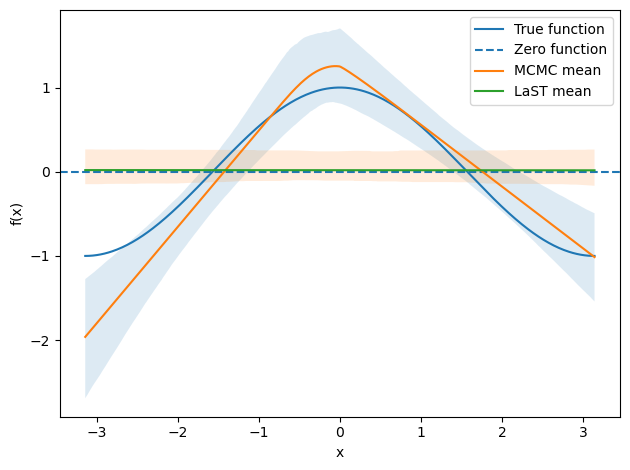

In [29]:
x_grid = torch.linspace(
    -torch.pi,
    torch.pi,
    400,
    device=device,
    dtype=X_train.dtype,
)[:, None]

signal_grid = torch.cos(
    x_grid[:, 0]
)

mcmc_grid = me.predict_draws(
    decoder,
    x_grid,
    mcmc_xi,
)

last_grid = me.predict_draws(
    model.decoder,
    x_grid,
    last_xi,
)

fig, ax = me.plot_function_1d(
    x=x_grid[:, 0].cpu(),
    signal=signal_grid.cpu(),
    mcmc_pred_draws=mcmc_grid,
    last_pred_draws=last_grid,
)